In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import sqlite3
from wordcloud import WordCloud

In [4]:
df = pd.read_csv('../data/chocolate_bar_ratings_2022_cleaned.csv')

Create a chart that shows a distribution (e.g., histogram, boxplot).

-Question(s) you're exploring: How many chocolate bars received each rating? Is the data skewed in a particular direction?

-I chose a histogram (or boxplot) because it helps you visualize the spread, skew, and shape of the data.    

-What does the chart help you notice? I noticed that the data is skewed toward the higher end of the rating scale. More bars are rated between 3.0 and 3.5 than any other value. In a normal distribution, most of the data would be clustered around the mean of 2.5 on a 1-4 rating scale. In this case, the mean, as seen in the data exploration, is 3.1. 

-I chose a neutral color that is accessible. I used https://www.nceas.ucsb.edu/sites/default/files/2022-06/Colorblind%20safe%20Color%20Schemes.pdf and https://rgbcolorcode.com/color/converter to ensure that all colors used in this notebook are accessible.
 
-I chose 20 bins. I thought 15 looked better visually but I thought it might be exaggerating the shape and skew of the data.  

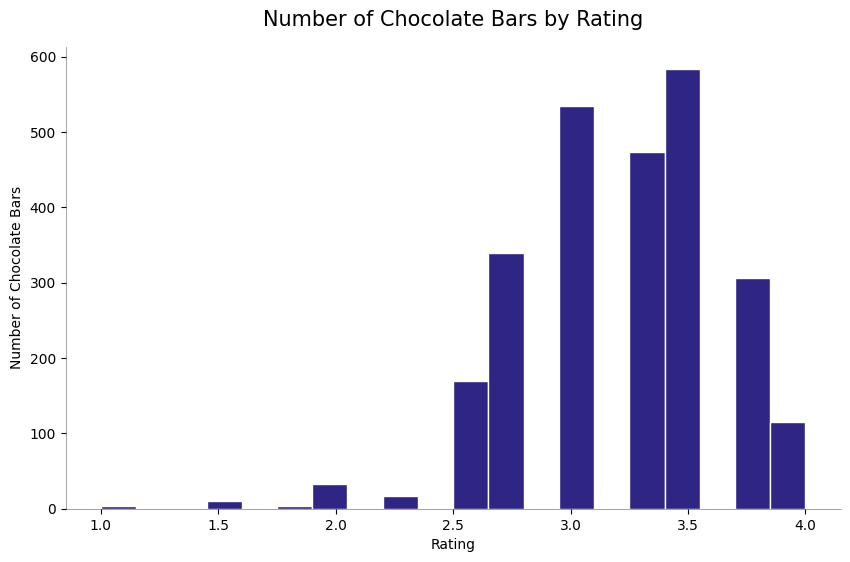

In [4]:
plt.figure(figsize=(10, 6))
plt.hist(
    df['Rating'],
    bins=20, 
    color='#2E2585',
    edgecolor='white'
)
#need to change the increments to include .25 and .75

plt.xlabel('Rating')
plt.ylabel('Number of Chocolate Bars')
plt.title('Number of Chocolate Bars by Rating', fontsize=15, pad=15)

ax = plt.gca()
for spine in ax.spines.values():
    spine.set_linewidth(0.5)
    spine.set_alpha(0.5)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.show()

I chose a histogram again to show the distribution of countries in which the beans are grown. I chose a neutral color and neutral language for the labels. This does not tell us anything other than how many bars come from beans grown in each country.

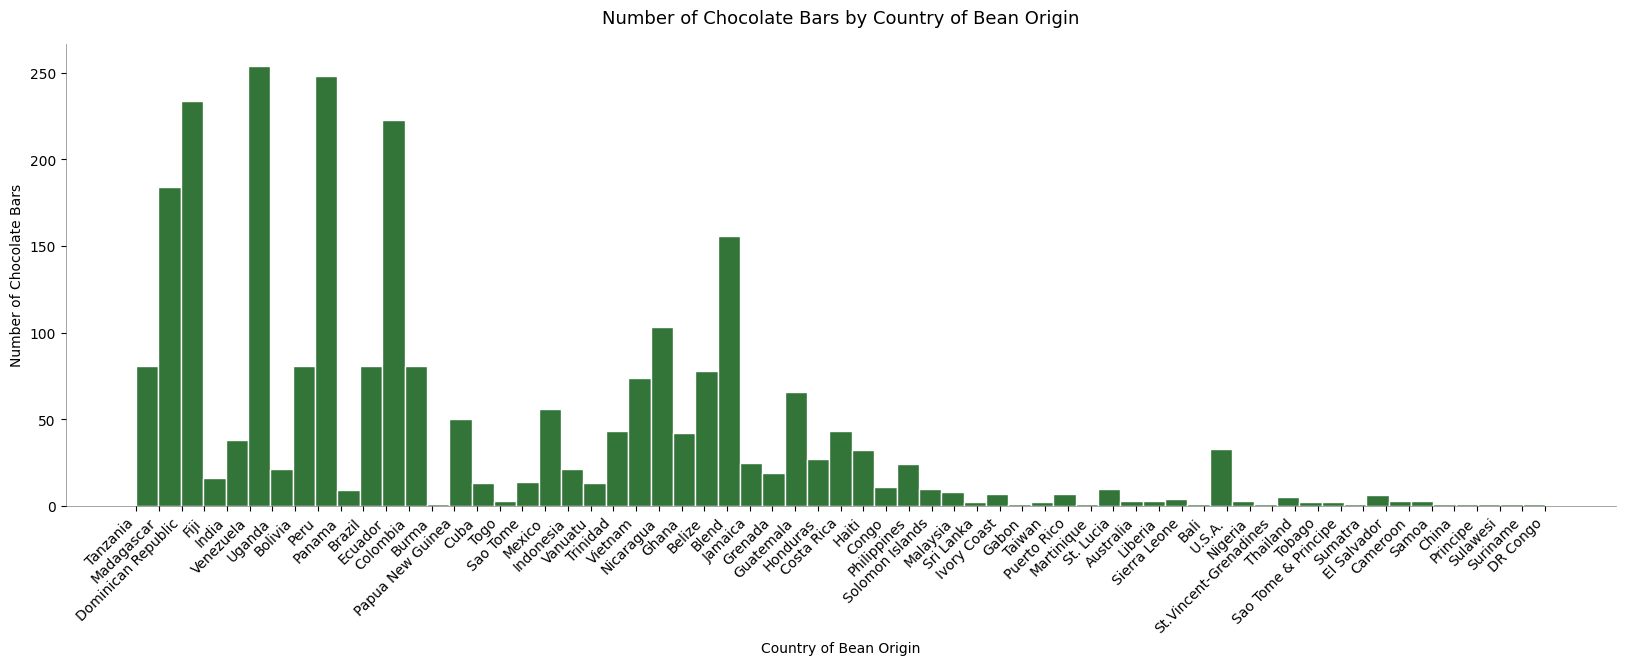

In [6]:
plt.figure(figsize=(20, 6))
plt.hist(
    df['Bean Origin'],
    bins=63, 
    color='#337538',
    edgecolor='white'
)

plt.xlabel('Country of Bean Origin')
plt.ylabel('Number of Chocolate Bars')
plt.title('Number of Chocolate Bars by Country of Bean Origin', fontsize=13, pad=15)
plt.xticks(rotation=45, ha='right')


ax = plt.gca()
for spine in ax.spines.values():
    spine.set_linewidth(0.5)
    spine.set_alpha(0.5)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.show()

I created a bar chart that shows the top 10 countries for bean production. I chose this chart because I thought that including 62 countries was too visually distracting and isn't meaningful. A bar chart is appropriate here for comparing quantities across variables.  I raised the y-axis limit to 350 to reduce the look of exaggerated data. The previous limit was 250, the height of the tallest bar. I chose a neutral, accessible color and neutral language for the labels.

In [7]:
highest_bean_origin = df['Bean Origin'].value_counts().head(10)
highest_bean_origin

Bean Origin
Venezuela             254
Peru                  248
Dominican Republic    234
Ecuador               223
Madagascar            184
Blend                 156
Nicaragua             103
Tanzania               81
Bolivia                81
Brazil                 81
Name: count, dtype: int64

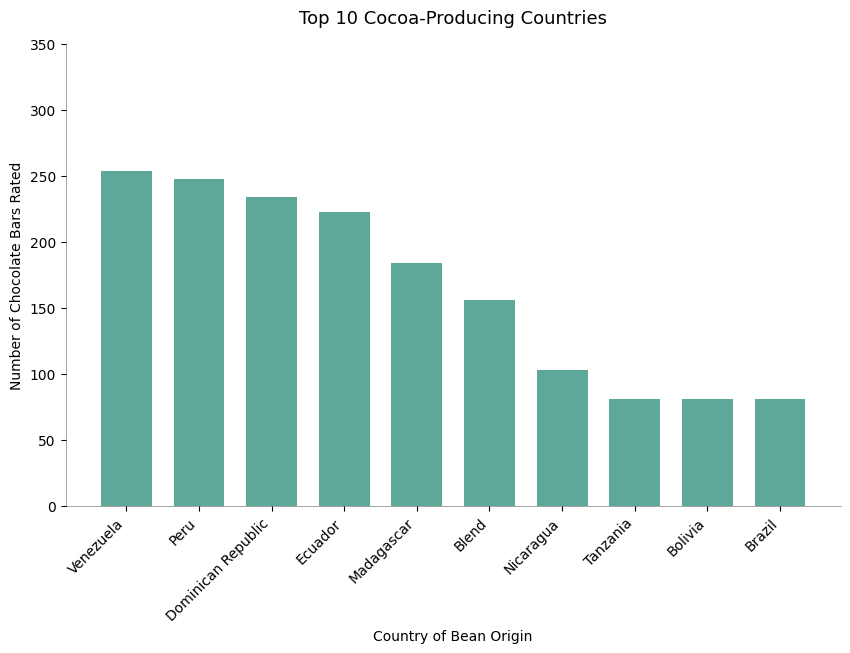

In [8]:
plt.figure(figsize=(10, 6))
plt.bar(highest_bean_origin.index, highest_bean_origin.values,
        color = "#5DA899",
        width = .7
        )

plt.xlabel('Country of Bean Origin')
plt.ylabel('Number of Chocolate Bars Rated')
plt.ylim(top = 350)
plt.title('Top 10 Cocoa-Producing Countries', fontsize=13, pad=15)
plt.xticks(rotation=45, ha='right')


ax = plt.gca()
for spine in ax.spines.values():
    spine.set_linewidth(0.5)
    spine.set_alpha(0.5)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.show()

    


Here is the distribution of chocolate bars produced in different countries.  I chose a histogram to show distribution.  Again, this does not tell us anything other than how many of the chocolate bars used in the dataset were produced in each country. Used a neutral, accessible color and neutral language for the labels. The tallest bar almost reaches the top of the graph. I tried increasing figure size the height of the y-axis to 15, but it goes off the page. Also, the graph is so small to begin with due to the large number of varibles, and I didn't want to raise the y-axis limit and make it any smaller. I believe this data is better visualized when reduced to the top 10 chocolate-producing countries.

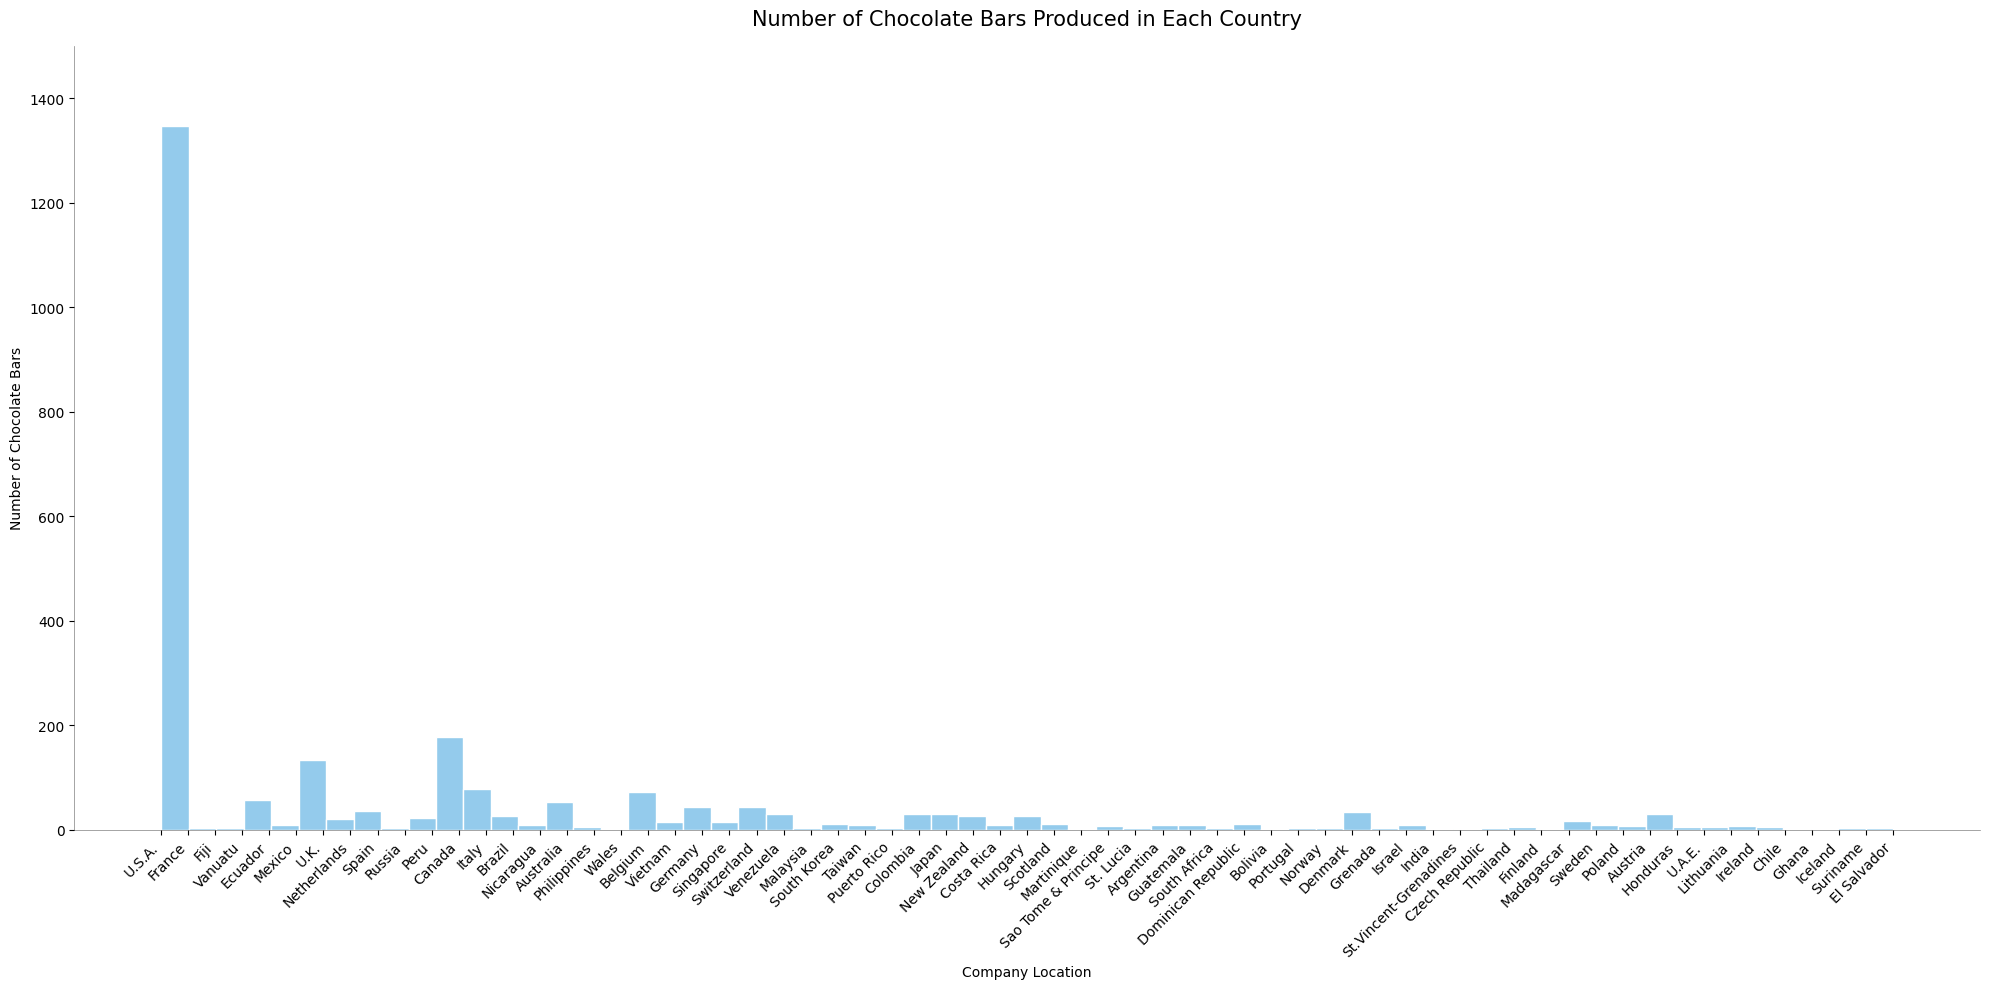

In [199]:
plt.figure(figsize=(20, 10))
plt.hist(
    df['Company Location'],
    bins=63, 
    color='#94CBEC',
    edgecolor='white'
)

plt.xlabel('Company Location')
plt.ylabel('Number of Chocolate Bars')
plt.ylim(top=1500)
plt.title('Number of Chocolate Bars Produced in Each Country', fontsize=15, pad=15)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

ax = plt.gca()
for spine in ax.spines.values():
    spine.set_linewidth(0.5)
    spine.set_alpha(0.5)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.show()

Here is a bar chart highlighting the top 10 countries in terms of chocolate bar production. I chose this chart because the histogram is too small and distracting with 60 + countries, and there's no meaningful order to the data. I thought that focusing on the top 10 would be more meaningful to audiences. What stands out in the following bar chart (and the above histogram) is that USA is the single largest producer of the chocolate bars rated. It is also interesting that Ecuador is in the top 10 of both the cocoa-producing and chocolate-producing countries. A bar chart is appropriate for this data because it gives quantities (number of bars rated) of categorical variables (top 10 countries). I ensured accuracy and avoided misleading data by using a y-axis that starts at zero, using a neutral color, and using simple, neutral language in the labels. I raised the y-axis limit to 1400 to reduce the appearance of exaggerated data (it previously went to just 1200, slightly beyond the tallest bar).

In [10]:
highest_company_location = df['Company Location'].value_counts().head(10)
highest_company_location

Company Location
U.S.A.         1168
France          179
Canada          178
U.K.            134
Italy            79
Belgium          72
Ecuador          58
Australia        53
Switzerland      44
Germany          43
Name: count, dtype: int64

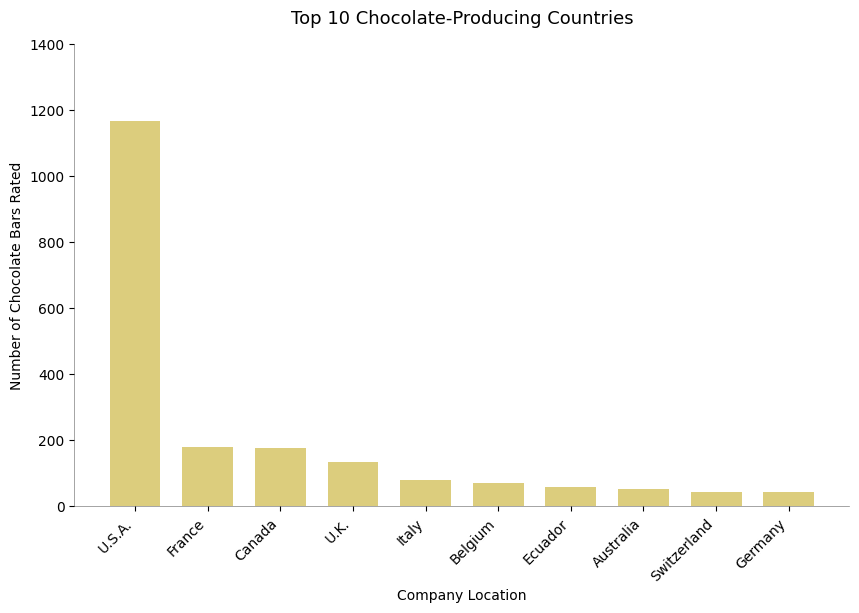

In [11]:
plt.figure(figsize=(10, 6))
plt.bar(highest_company_location.index, highest_company_location.values,
        color = '#DCCD7D',
        width = .7
        )

plt.xlabel('Company Location')
plt.ylabel('Number of Chocolate Bars Rated')
plt.ylim(top=1400)
plt.title('Top 10 Chocolate-Producing Countries', fontsize=13, pad=15)
plt.xticks(rotation=45, ha='right')


ax = plt.gca()
for spine in ax.spines.values():
    spine.set_linewidth(0.5)
    spine.set_alpha(0.5)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.show()

Create a chart that shows a comparison (e.g., bar chart, grouped bar, count plot). For this chart, I will explore the country of bean origin and the cocoa percentage.  The x-axis is a categorical variable (something like country of bean origin, manufacturer, company location, etc). The y-axis is some kind of measurement (e.g., cocoa percentage, rating, year). 

In [14]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2588 entries, 0 to 2587
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   REF               2588 non-null   int64  
 1   Company           2588 non-null   str    
 2   Company Location  2588 non-null   str    
 3   Review Date       2588 non-null   int64  
 4   Bean Origin       2588 non-null   str    
 5   Bar Name          2588 non-null   str    
 6   Cocoa %           2588 non-null   float64
 7   Ingredients       2588 non-null   str    
 8   Characteristics   2588 non-null   str    
 9   Rating            2588 non-null   float64
dtypes: float64(2), int64(2), str(6)
memory usage: 202.3 KB


Group by bean origin (or company location) and calculate the average cocoa percentage using .mean(). I also want to order these values from least to most cocoa percentage using .sort_values()

In [15]:
avg_cocoa_percent = df.groupby('Bean Origin')['Cocoa %'].mean().sort_values()
avg_cocoa_percent 

Bean Origin
Martinique    42.000000
Bali          65.000000
Tobago        65.000000
Sulawesi      66.000000
DR Congo      68.000000
                ...    
Ecuador       73.253363
Cuba          74.153846
Gabon         75.000000
Principe      77.000000
Samoa         82.333333
Name: Cocoa %, Length: 63, dtype: float64

Create a chart that shows a comparison (e.g., bar chart, grouped bar, count plot).    
-I am exploring the relationship between the bean origin and the cocoa percentage.        
-I chose this type of chart because a bar chart compares quantities (cocoa percentage) across categories (bean origin).      
-This chart doesn't really tell me much. Most of the cocoa percentages are in the 70% range.    

 I think that the percent of cocoa in the chocolate would depend on the quantities of other ingredients added to it (the more sweetener, lecithin, vanilla, etc, the lower the percentage of cocoa (beans and cocoa butter combined)), not on where the bean comes from. A better chart might be seeing how the cocoa percentage influences the rating. But then again, that might have more to do with the taster's preferences.    

I ensured accuracy and avoided misleading design by using neutral language, neutral colors, simple design, and average cocoa percentages.    

Given that most of the values are in the 70% range, I don't think it would vary much by company or company location, either.  

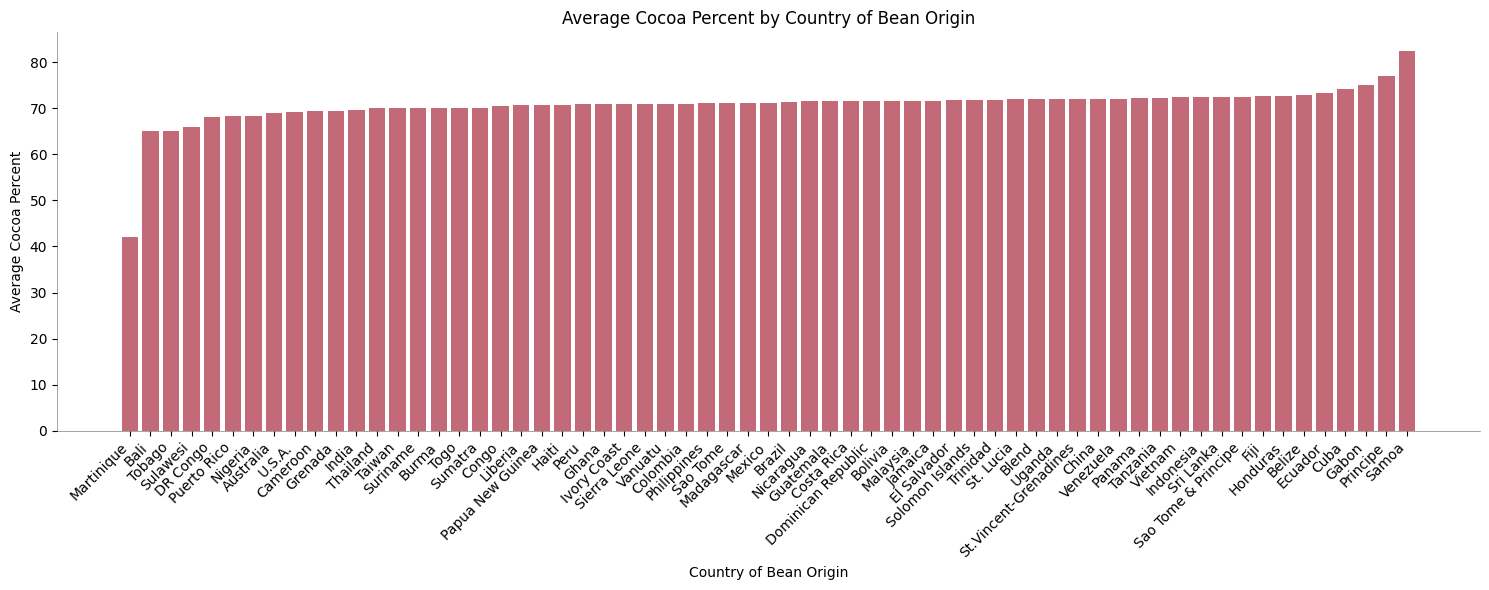

In [16]:
plt.figure(figsize=(15, 6))
plt.bar(avg_cocoa_percent.index, 
        avg_cocoa_percent.values, 
        color='#C26A77')

ax = plt.gca()
for spine in ax.spines.values():
    spine.set_linewidth(0.5)
    spine.set_alpha(0.5)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.xlabel('Country of Bean Origin')
plt.ylabel('Average Cocoa Percent')
plt.title('Average Cocoa Percent by Country of Bean Origin')
plt.xticks(rotation=45, ha = 'right')
plt.tight_layout()

plt.show()



I tried several groupby() comparisons in the following cells.

In [17]:
avg_country_origin_rating = df.groupby('Bean Origin')['Rating'].mean().sort_values()
avg_country_origin_rating

Bean Origin
Bali                     2.500000
Puerto Rico              2.714286
Principe                 2.750000
Martinique               2.750000
St.Vincent-Grenadines    2.750000
                           ...   
Congo                    3.318182
Solomon Islands          3.450000
China                    3.500000
Sao Tome & Principe      3.500000
Tobago                   3.625000
Name: Rating, Length: 63, dtype: float64

In [18]:
avg_cocoa_percent_rating = df.groupby('Cocoa %')['Rating'].mean().sort_values()
avg_cocoa_percent_rating

Cocoa %
53.0     2.000000
91.0     2.166667
100.0    2.285714
89.0     2.625000
99.0     2.625000
42.0     2.750000
46.0     2.750000
57.0     2.750000
60.5     2.750000
72.5     2.750000
84.0     2.812500
55.0     2.859375
81.0     2.916667
61.0     2.964286
90.0     2.972222
62.0     2.984375
85.0     3.000000
83.0     3.000000
60.0     3.005435
76.0     3.021429
82.0     3.041667
71.0     3.068182
80.0     3.086111
77.0     3.098837
73.5     3.125000
58.0     3.125000
71.5     3.125000
75.0     3.161859
65.0     3.163978
64.0     3.195946
73.0     3.197761
74.0     3.213768
72.0     3.216828
88.0     3.218750
56.0     3.250000
79.0     3.250000
87.0     3.250000
86.0     3.250000
70.0     3.265421
68.0     3.290000
67.0     3.335714
66.0     3.348214
78.0     3.386364
69.0     3.461538
63.0     3.500000
50.0     3.750000
Name: Rating, dtype: float64

This didn't do what I wanted it to do. It took each cocoa percentage value (first column) and gave an average of the ratings for each cocoa percent (second column).  It might be useful to graph anyway, to see if there's a relationship between the amount of cocoa in a chocolate bar and the rating it gets.  I think in order to show any relationship, you would have to sort the cocoa percentages from lowest to highest.  


Create a chart that shows a relationship or pattern (e.g., line chart, scatterplot)  
I chose a scatterplot  
-I am exploring the relationship between cocoa percentage and the chocolate bar rating.  
-I chose this type of chart because it compares two numeric variables.  
-This scatterplot helped me notice that most of chocolate bars with 60-80% cocoa had ratings between 2.5 - 4.0.   
-I ensured accuracy and avoided misleading design by using neutral language and didn't omit any data.  

In [94]:
avg_rating_cocoa_percent = df.groupby('Rating')['Cocoa Percent'].mean().sort_values(ascending=False)
avg_rating_cocoa_percent

Rating
1.75    90.666667
1.50    84.800000
1.00    78.250000
2.00    76.575758
2.25    73.294118
2.75    72.056047
3.00    71.705993
2.50    71.653846
3.25    71.405063
3.50    71.211473
3.75    71.014706
4.00    70.756522
Name: Cocoa Percent, dtype: float64

In [115]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2588 entries, 0 to 2587
Data columns (total 10 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   REF                               2588 non-null   int64  
 1   Company (Manufacturer)            2588 non-null   str    
 2   Company Location                  2588 non-null   str    
 3   Review Date                       2588 non-null   int64  
 4   Country of Bean Origin            2588 non-null   str    
 5   Specific Bean Origin or Bar Name  2588 non-null   str    
 6   Cocoa Percent                     2588 non-null   float64
 7   Ingredients                       2501 non-null   str    
 8   Most Memorable Characteristics    2588 non-null   str    
 9   Rating                            2588 non-null   float64
dtypes: float64(2), int64(2), str(6)
memory usage: 202.3 KB


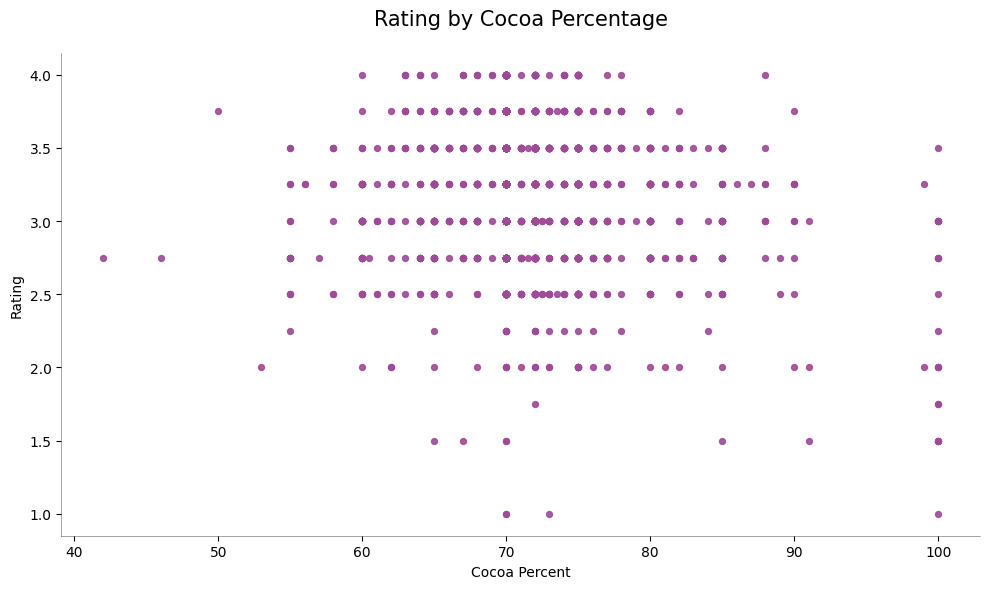

In [19]:
plt.figure(figsize=(10, 6))
plt.scatter(df['Cocoa %'], 
            df['Rating'], 
            color = '#9F4A96', 
            alpha = 0.9,
            s = 18)

ax = plt.gca()
for spine in ax.spines.values():
    spine.set_linewidth(0.5)
    spine.set_alpha(0.5)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.xlabel('Cocoa Percent')
plt.ylabel('Rating')
plt.title('Rating by Cocoa Percentage', fontsize=15, pad=20)

plt.tight_layout()

plt.show()

I created a heatmap to show possible correlation between cocoa percentage and chocolate bar rating. As you can see, there is slight negative correlation between cocoa percentage and rating (about -0.25). It is not a significant relationship. Similarly, there is an insignificant positive correlation (about .10) between rating and review date, and an insignificant negative correlation (about 
-0.10) between cocoa percent and review date. I chose the the color scheme from https://matplotlib.org/stable/users/explain/colors/colormaps.html#sequential and Color Brewer to be accessible for colorblindness. 

In [20]:
# I had to drop the REF column again, just for this plot because it's just an ID number.
df = df.drop('REF', axis = 1)

In [21]:
#find out which variables are numeric
numeric_df = df.select_dtypes(include=[np.number])
numeric_df.head()

,Review Date,Cocoa %,Rating
0,2019,76.0,3.25
1,2019,76.0,3.75
2,2019,76.0,3.50
3,2021,68.0,3.00
4,2021,68.0,3.50


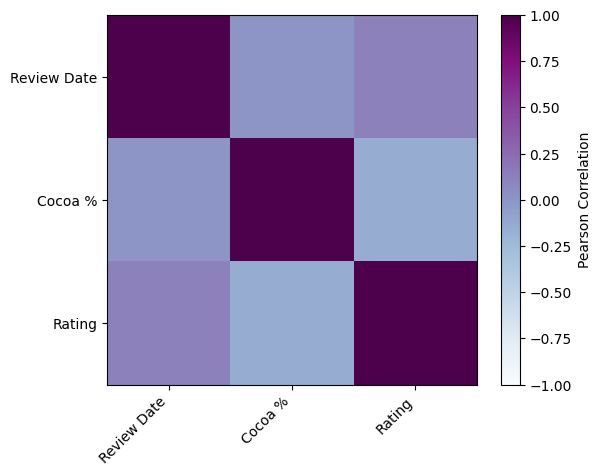

In [22]:
corr = numeric_df.corr()

im = plt.imshow(corr, vmin=-1, vmax=1, cmap='BuPu') #coolwarm
plt.colorbar(im, label='Pearson Correlation')

plt.xticks(range(len(corr.columns)), corr.columns, rotation = 45, ha='right')
plt.yticks(range(len(corr.columns)), corr.columns)

plt.show()

To explore how bean origin affects chocolate bar rating, I will use another bar plot. Bar plots are appropriate for comparing quantities across categories. In this case, I will see which countries of origin have the most outstanding (4.0) chocolate bars.

In [23]:
highest_rating_bean_origin = df.groupby('Bean Origin')['Rating'].max().sort_values(ascending=False)
highest_rating_bean_origin 

Bean Origin
Belize                   4.00
Bolivia                  4.00
Blend                    4.00
Brazil                   4.00
Dominican Republic       4.00
                         ... 
Sri Lanka                3.00
Principe                 2.75
Martinique               2.75
St.Vincent-Grenadines    2.75
Bali                     2.50
Name: Rating, Length: 63, dtype: float64

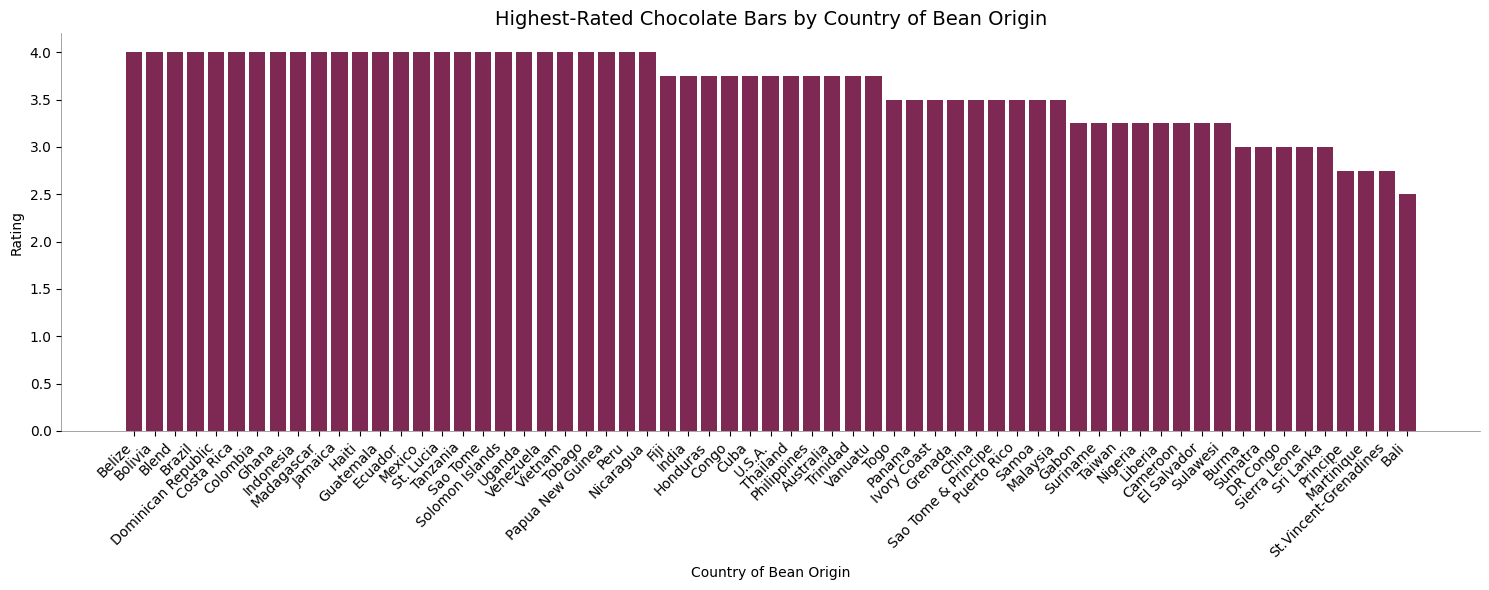

In [186]:
plt.figure(figsize=(15, 6))
plt.bar(
    highest_rating_bean_origin.index,
    highest_rating_bean_origin.values,
    color='#7E2954')

ax = plt.gca()
for spine in ax.spines.values():
    spine.set_linewidth(0.5)
    spine.set_alpha(0.5)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.xlabel('Country of Bean Origin')
plt.ylabel('Rating')
plt.title("Highest-Rated Chocolate Bars by Country of Bean Origin", fontsize=14)
plt.xticks(rotation=45, ha = 'right')
plt.tight_layout()

plt.show()

This data was collected from 2006 - 2022. I would like to add a line graph to explore how the number of reviews changed over time.  It might also be useful to explore how ratings change from year to year. 

I chose a line graph because a line graph shows how a variable changes over time.

I changed the y axis to start with zero to eliminate the appearance of exaggerated data. I used one of the colors in my accessible color palette. It appears that average chocolate bar ratings did not vary much from year to year. The yearly averages tended to hover between  3.0 and 3.5, which coincides with the overall mean of 3.19 that was calculated earlier in this analysis. I started to add an xtick for each year (vs every other year) but I like the simplicity of the x-axis without it, and all of the data points are still there. 

In [24]:
annual_avg_rating = df.groupby('Review Date')['Rating'].mean().round(2)
annual_avg_rating

Review Date
2006    3.00
2007    3.10
2008    3.00
2009    3.07
2010    3.15
2011    3.26
2012    3.18
2013    3.20
2014    3.19
2015    3.24
2016    3.23
2017    3.36
2018    3.19
2019    3.13
2020    3.26
2021    3.32
2022    3.28
Name: Rating, dtype: float64

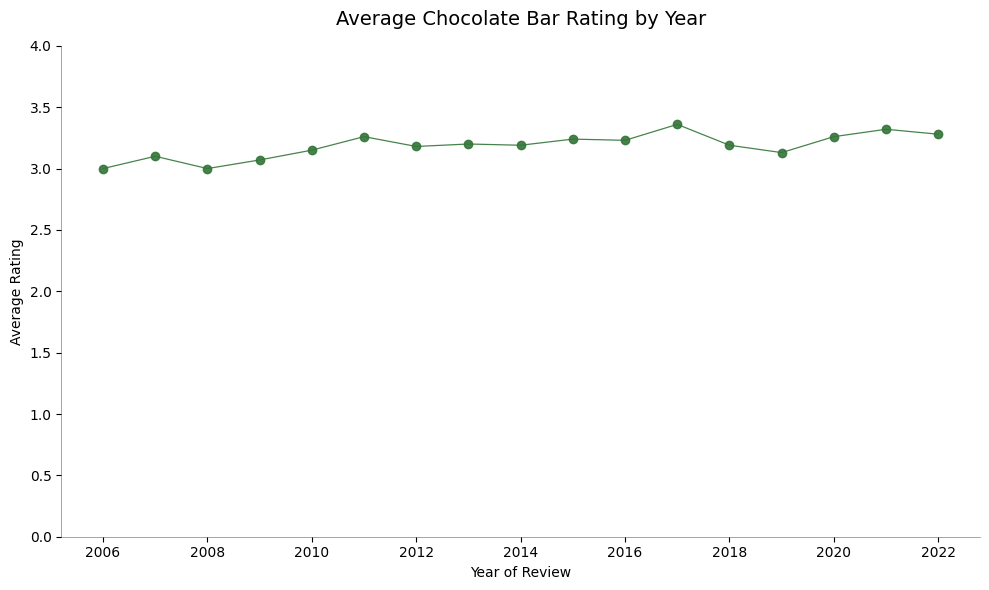

In [25]:
plt.figure(figsize=(10,6))
plt.plot(annual_avg_rating.index, 
         annual_avg_rating.values,
         linewidth=.9,
         marker = 'o',
         color='#337538',
         alpha=.9)

ax = plt.gca()
for spine in ax.spines.values():
    spine.set_linewidth(0.5)
    spine.set_alpha(0.5)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.xlabel('Year of Review')
plt.ylabel('Average Rating')
plt.ylim(0, 4)
plt.title("Average Chocolate Bar Rating by Year", fontsize=14, pad=15)
#plt.xticks((np.arange(2006, 2023, 1.0)), rotation=45, ha = 'right')
plt.tight_layout()

plt.show()

Next, I'd like to create a histogram to view the distribution of number of reviews according to year, since there were much fewer reviews during some years than others.

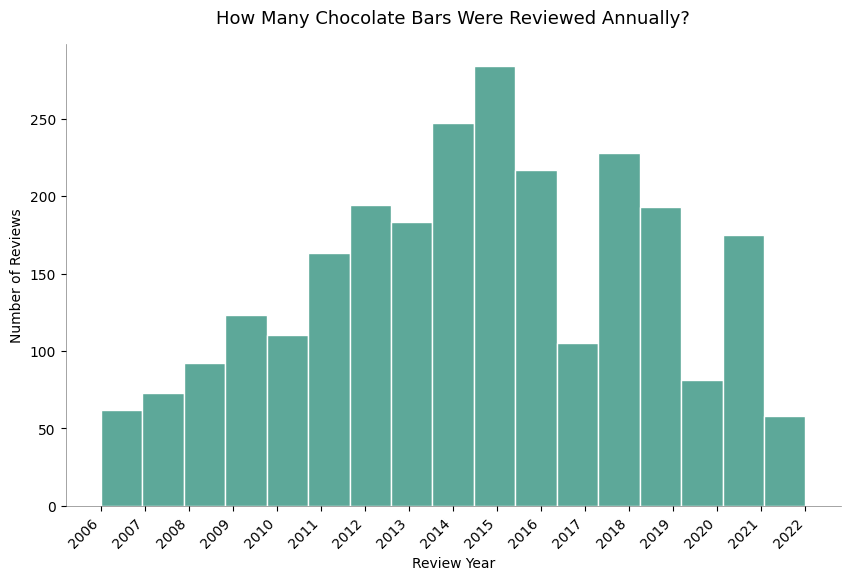

In [26]:
plt.figure(figsize=(10, 6))
plt.hist(
    df['Review Date'],
    bins=17, 
    color='#5DA899',
    edgecolor='white'
)

plt.xlabel('Review Year')
plt.ylabel('Number of Reviews')
plt.title('How Many Chocolate Bars Were Reviewed Annually?', fontsize=13, pad=15)
plt.xticks((np.arange(2006, 2023, 1.0)), rotation=45, ha='right')#plt.xticks((np.arange(2006, 2023, 1.0)), rotation=45, ha = 'right')


ax = plt.gca()
for spine in ax.spines.values():
    spine.set_linewidth(0.5)
    spine.set_alpha(0.5)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.show()

I created an Entity Relationship Diagram, and now it is time to build relational tables with Sqlite3.  I followed the Week 4 workflow tutorial, as well as class recordings from 7/18/26 and 7/25/26.

In [5]:
# make the database connection
conn = sqlite3.connect('chocolate_bar_ratings_2022.db')

chocolate_bar_df = df[['REF', 'Bar Name', 'Company', 'Cocoa %', 'Ingredients', 'Rating']].drop_duplicates().rename(columns = {
    'Bar Name': 'bar_name',
    'Company': 'company',
    'Cocoa %': 'cocoa_%',
    'Ingredients': 'ingredients',
    'Rating': 'rating'
})

bean_origin_df = df[['Characteristics', 'Rating', 'REF']].drop_duplicates().rename(columns = {
    'Characteristics': 'characteristics',
    'Rating': 'rating'
})

reviews_df = df[['Review Date', 'Rating', 'Ingredients', 'Characteristics']].drop_duplicates().rename(columns = {
    'Review Date': 'review_date',
    'Rating': 'rating',
    'Ingredients': 'ingredients',
    'Characteristics': 'characteristics'
})

manufacturer_country_df = df[['Rating', 'Ingredients', 'Company Location']].drop_duplicates().rename(columns = {
    'Rating': 'rating',
    'Ingredients': 'ingredients', 
    'Company Location': 'company_location'
})

chocolate_bar_df.to_sql('chocolate_bar', conn, index = False, if_exists = 'replace')
bean_origin_df.to_sql('bean_origin', conn, index = False, if_exists = 'replace')
reviews_df.to_sql('reviews', conn, index = False, if_exists = 'replace')
manufacturer_country_df.to_sql('manufacturer_country', conn, index = False, if_exists = 'replace')
conn.commit()

The database was created successfully. I was unable to create it in the data folder because it gave me an error message each time. Also, anytime I tried to move a csv file into the data folder, Python would not read it. I moved these into the data folder with file explorer.   

Also, I can make separate csv files for each of these based on the Thursday bookstore demo. I will do this in the next cell.     

I saved each of the new dfs as its own csv file.



In [7]:
chocolate_bar_df.to_csv('../data/chocolate_bar.csv')
bean_origin_df.to_csv('../data/bean_origin.csv')
reviews_df.to_csv('../data/reviews.csv')
manufacturer_country_df.to_csv('../data/manufacturer_country.csv')

Now I will make some queries based on my project questions.    

What are the characteristics and ingredients of the highest-rated chocolate bars? 

In [8]:
query1 = """
SELECT 
    c.rating,
    r.rating,
    r.characteristics
FROM chocolate_bar c
JOIN reviews r ON c.rating = r.rating
WHERE c.rating = 4.0
"""    

In [9]:
result1 = pd.read_sql_query(query1, conn)
result1

,rating,rating,characteristics
0,4.0,4.0,"balanced, cherry, choco"
1,4.0,4.0,"balanced, nuts, strawberry"
2,4.0,4.0,"banana, pear, spice, cheese"
3,4.0,4.0,"banana, yogurt, cocoa"
4,4.0,4.0,"banana,dairy, cocoa"
...,...,...,...
13220,4.0,4.0,"tangy, floral, spicy, cocoa"
13221,4.0,4.0,"tart, lemon, smoke"
13222,4.0,4.0,"tart, red berry, smoke"
13223,4.0,4.0,"tart, roasted cocoa"


Find the number of rows with 4.0 rating.

In [43]:
query2 = """
SELECT COUNT (c.rating)
FROM chocolate_bar c
WHERE c.rating = 4.0
"""

In [44]:
result2 = pd.read_sql_query(query2, conn)
result2

,COUNT (c.rating)
0,115


This matches the 4.0 rating value counts (115) in the original exploratory data analysis notebook.  

I want to find the most frequently occurring words in the characteristics column for bars rated 4.0. First, I need to select just the characteristics column, so it creates its own series.  

In [55]:
query3 = """
SELECT 
    r.characteristics
FROM reviews r
WHERE r.rating = 4.0
"""   

In [62]:
result3 = pd.read_sql_query(query3, conn)
result3

,characteristics
0,"oily, nut, caramel, raspberry"
1,"sweet, cocoa, tangerine"
2,"delicate, hazelnut, brownie"
3,"light color, fruit, yogurt"
4,"strong spice, intense pepper"
...,...
110,"green,unripened fruit,banana"
111,"intense, dark berry, grapes"
112,"complex, hazelnut, dairy, fruit"
113,"rich cocoa, spicy, cinamon"


I'm going to make a word cloud with this. The larger the word, the more frequently it occurs.

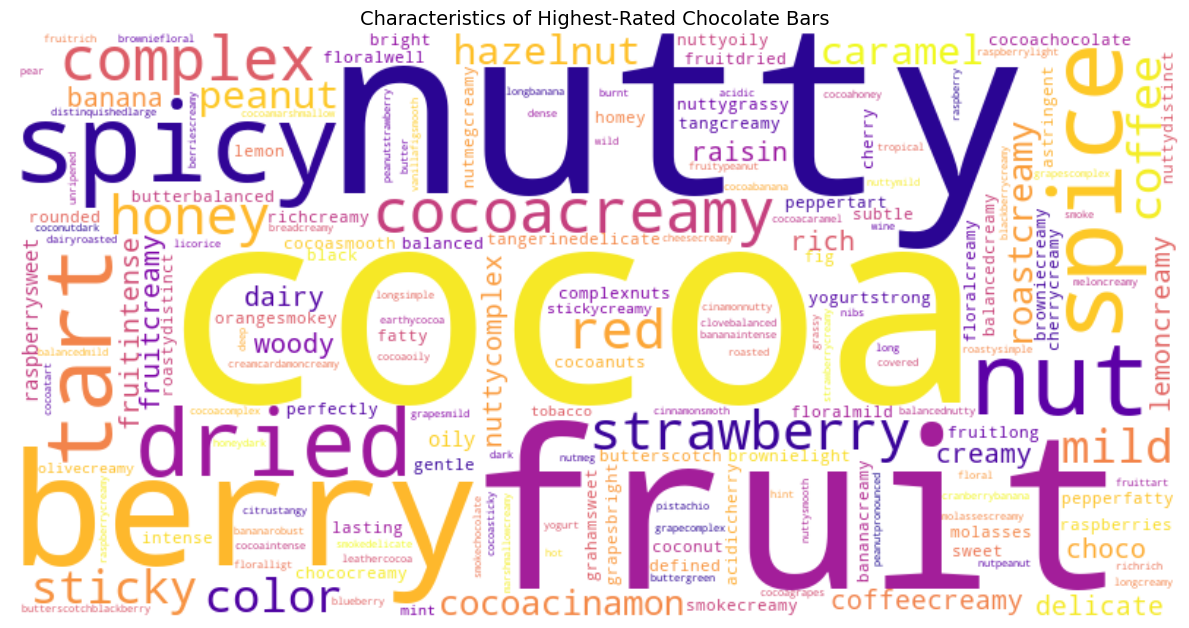

In [76]:
text = ''.join(result3['characteristics'])

wc = WordCloud(width=800, height=400, background_color='white', colormap='plasma').generate(text)
plt.figure(figsize=(12, 8))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.title('Characteristics of Highest-Rated Chocolate Bars', fontsize=14)
plt.tight_layout()
plt.show()

Let's find the most common characteristics in the lowest-rated bars (1.0 rating):

In [86]:
query4 = """
SELECT 
    r.characteristics
FROM reviews r
WHERE r.rating BETWEEN 0 AND 1.99
"""    

In [87]:
result4 = pd.read_sql_query(query4, conn)
result4

,characteristics
0,"cocoa, dominate off note"
1,"very nutty, very bitter"
2,"acidic, bitter, dry"
3,"cardboard, very bitter, floral"
4,"klingy, hint of fruit, very bitter"
5,"bitter, cocoa"
6,"chalky, musty, very bitter"
7,high intensity bitter
8,this is not chocolate
9,"acidic, astringent, unpleasant"


Another wordcloud, this time for the characteristics of the lowest-rated bars:

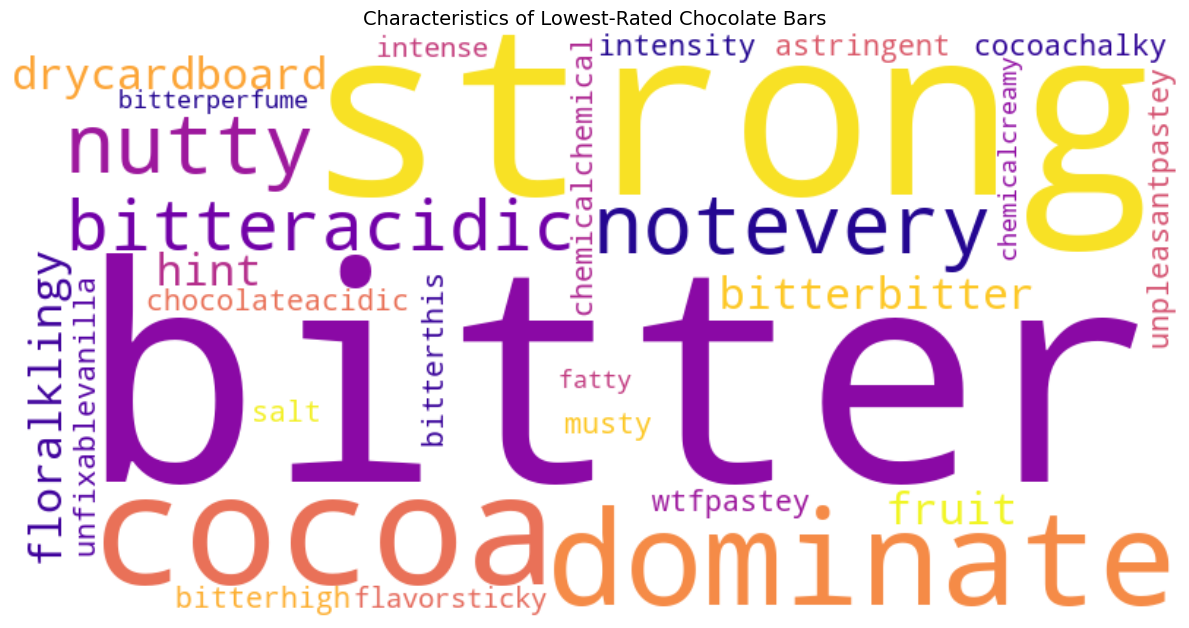

In [ ]:
text = ''.join(result4['characteristics'])

wc = WordCloud(width=800, height=400, background_color='white', colormap='plasma').generate(text)   
plt.figure(figsize=(12, 8))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.title('Characteristics of Lowest-Rated Chocolate Bars', fontsize=14)
plt.tight_layout()
plt.show()

As expected, the words in the highest-rated bars are positive and most of the words in the lowest-rated bars are negative.

Now I would like to see the most common ingredients in the highest rated chocolate bars.

In [10]:
#Locating the ingredients in the highest-rated bars
query5 = """ 
SELECT 
    c.rating,
    m.ingredients
FROM chocolate_bar c
JOIN manufacturer_country m ON c.rating = m.rating
WHERE c.rating = 4.0
"""

In [11]:
result5 = pd.read_sql_query(query5, conn)
result5

,rating,ingredients
0,4.0,"2- B,S"
1,4.0,"2- B,S"
2,4.0,"2- B,S"
3,4.0,"2- B,S"
4,4.0,"2- B,S"
...,...,...
3100,4.0,"5- B,S,C,V,L"
3101,4.0,"5- B,S,C,V,L"
3102,4.0,"5- B,S,C,V,L"
3103,4.0,"5- B,S,C,V,L"


How many distinct values did the above query (query5) return?

In [15]:
query6 = """
SELECT DISTINCT 
    c.ingredients
FROM chocolate_bar c
WHERE c.rating = 4.0
"""

In [16]:
result6 = pd.read_sql_query(query6, conn)
result6

,ingredients
0,"4- B,S,C,L"
1,"3- B,S,C"
2,"4- B,S,C,V"
3,"2- B,S"
4,"5- B,S,C,V,L"


It appears that highly-rated chocolate bars contain five unique combinations of ingredients:     
1. Beans, sugar, cocoa butter, lecithin    
2. Beans, sugar, cocoa butter    
3. Beans, sugar, cocoa butter, vanilla
4. Beans, sugar
5. Beans, Sugar, cocoa butter, vanilla, lecithin

What are the characteristics and ingredients of the lowest-rated bars?

In [ ]:
conn.close()